In [1]:
from pyPolCal.on_sky import write_fits_info_to_csv_psf

/home/thomasmc/miniconda3/envs/charisenv_2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# writing csv for hd35532, an unpol std
cubedir = '/home/thomasmc/charis_mm_testing/HD35532/cubes/data/raw'
rawdir = '/home/thomasmc/charis_mm_testing/HD35532/raw'
centroid_guesses = ([68,81],[132,114]) # guesses for PSF centroids
aper_radii = [18,18] # using <~3X FWHM for aperture radius due to space
bkgd_annuli_radii = ([18,26],[18,28]) # annuli for background subtraction
box_size = 51 # box for centroid finder to search

for bin in range(0,22):
    csv_out = f'/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD35532/bin{bin}.csv'
    write_fits_info_to_csv_psf(cubedir,csv_out,centroid_guesses=centroid_guesses,
                               box_size=box_size,wavelength_bin=bin,auto_annuli=True,max_fwhm=[15,15],plot_every_x=300,mask=False)

In [4]:
# cleaning up the csv, removing the first row from each of these
import pandas as pd

for bin in range(22):
    csvpath = f"/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD35532/bin{bin}.csv"
    df = pd.read_csv(csvpath)
    df = df.iloc[1:]  # Remove the first row
    df.to_csv(csvpath, index=False)

These are pretty saturated.

In [ ]:
# now bd343631, another unpol std
cubedir = '/home/thomasmc/charis_mm_testing/BD343631-broadband-unpol/cubes/data/raw'
rawdir = '/home/thomasmc/charis_mm_testing/BD343631-broadband-unpol/raw'
centroid_guesses = ([65,83],[133,118])# guesses for PSF centroids
box_size = 51 # box for centroid finder to search

for bin in range(0,22):
    csv_out = f'/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/BD343631/bin{bin}.csv'
    write_fits_info_to_csv_psf(cubedir,csv_out,raw_cube_path=rawdir,centroid_guesses=centroid_guesses,
                               box_size=box_size,wavelength_bin=bin,auto_annuli=True,max_fwhm=[15,15],plot_every_x=75)

Some of these psfs had trouble fitting in the higher wavlengths

In [ ]:
# hd 25532
cubedir = '/home/thomasmc/charis_mm_testing/HD25532/cubes/data/raw/good_frames'
centroid_guesses = ([68,81],[132,114])
box_size = 51
for bin in range(0,22):
    csv_out = f'/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD25532/bin{bin}.csv'
    write_fits_info_to_csv_psf(cubedir,csv_out,centroid_guesses=centroid_guesses,
                               box_size=box_size,wavelength_bin=bin,auto_annuli=True,max_fwhm=[15,15],plot_every_x=75)

In [12]:
# remove the first two entires and last 3 entries from hd 25532

for bin in range(22):
    csvpath = f"/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD25532/bin{bin}.csv"
    df = pd.read_csv(csvpath)
    df = df.iloc[2:-3]  # Remove the first two rows and last three rows
    df.to_csv(csvpath, index=False)

In [ ]:
# hd 40280, this one is actually from august
cubedir = '/home/thomasmc/charis_mm_testing/HD40280/cubes/data/raw'
centroid_guesses = ([68,81],[132,114])
box_size = 51
for bin in range(0,22):
    csv_out = f'/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD40280/bin{bin}.csv'
    write_fits_info_to_csv_psf(cubedir,csv_out,centroid_guesses=centroid_guesses,
                               box_size=box_size,wavelength_bin=bin,auto_annuli=True,max_fwhm=[15,15],plot_every_x=75)

In [6]:
# cleaning up csv, removing last entry from each one
import pandas as pd

for bin in range(22):
    csv_file = f'/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD40280/bin{bin}.csv'
    df = pd.read_csv(csv_file)
    df = df[:-1]  # Remove last entry
    df.to_csv(csv_file, index=False)

In [14]:
# combine bd343631, hd40280, and hd35532 into one csv per bin
import pandas as pd

for bin in range(22):
    df1 = pd.read_csv(f"/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/BD343631/bin{bin}.csv")
    df2 = pd.read_csv(f"/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD40280/bin{bin}.csv")
    df3 = pd.read_csv(f"/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD35532/bin{bin}.csv")
    combined = pd.concat([df1, df2, df3])
    combined.to_csv(f"../datacsvs/onsky_csvs/BD343631_HD40280_HD35532/bin{bin}.csv", index=False)


In [5]:
# getting the model ready by defining custom mueller matrices

from pyPolCal.mm_registry import register_mm_function
from pyMuellerMat.common_mm_functions import elliptical_retarder_function, wollaston_prism_function
from pyPolCal.csv_tools import model_data
from pyPolCal.constants import wavelength_bins
import numpy as np

wavelength_fits_dir = '../fitted_p_dicts/internalcal_july2025_pickout' # path to fitted p dicts
wavelength_fits_df = model_data(wavelength_fits_dir) # saving to DataFrame
derotator_phi_h = wavelength_fits_df['image_rotator_phi_h'].to_numpy() # linear h retardance
derotator_phi_45 = wavelength_fits_df['image_rotator_phi_45'].to_numpy() # linear 45 retardance
derotator_phi_r = wavelength_fits_df['image_rotator_phi_r'].to_numpy() # circular retardance
wollaston_eta = wavelength_fits_df['wollaston_eta'].to_numpy()

@register_mm_function()
def fitted_derotator_function_july_2025(wavelength=500): # Only keyword arguments!
    phi_h = derotator_phi_h
    phi_45 = derotator_phi_45
    phi_r = derotator_phi_r

    # Interpolating retardance as a function of wavelength 
    phi_h_interp = np.interp(wavelength, wavelength_bins, phi_h)
    phi_45_interp = np.interp(wavelength, wavelength_bins, phi_45)
    phi_r_interp = np.interp(wavelength, wavelength_bins, phi_r)

    # using pyMuellerMat's elliptical retarder function
    return elliptical_retarder_function(phi_h_interp, phi_45_interp, phi_r_interp)

@register_mm_function()
def fitted_wollaston_function_july_2025(beam='o',wavelength=500): # Only keyword arguments!
    eta = wollaston_eta

    # Interpolating retardance as a function of wavelength
    eta_interp = np.interp(wavelength, wavelength_bins, eta)

    # using pyMuellerMat's elliptical retarder function
    return wollaston_prism_function(beam=beam,eta=eta_interp)

This fitting code is copy pasted from the tutorial notebook

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

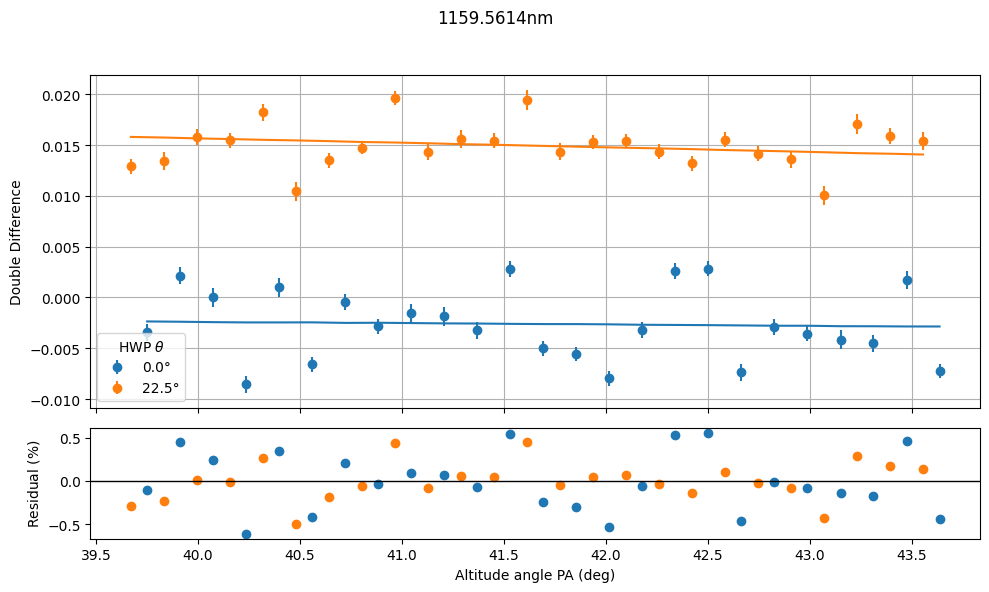

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

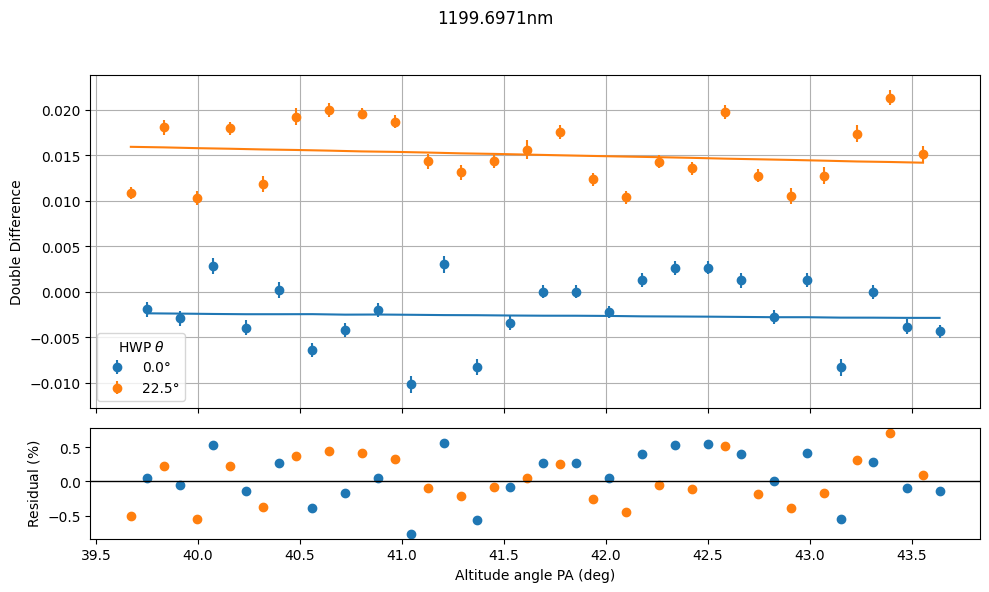

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

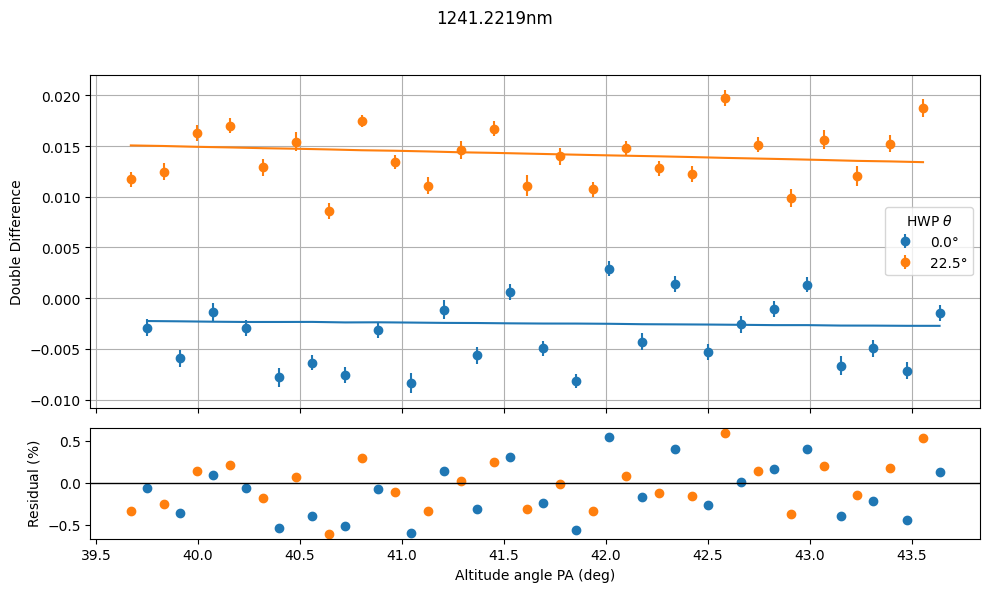

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

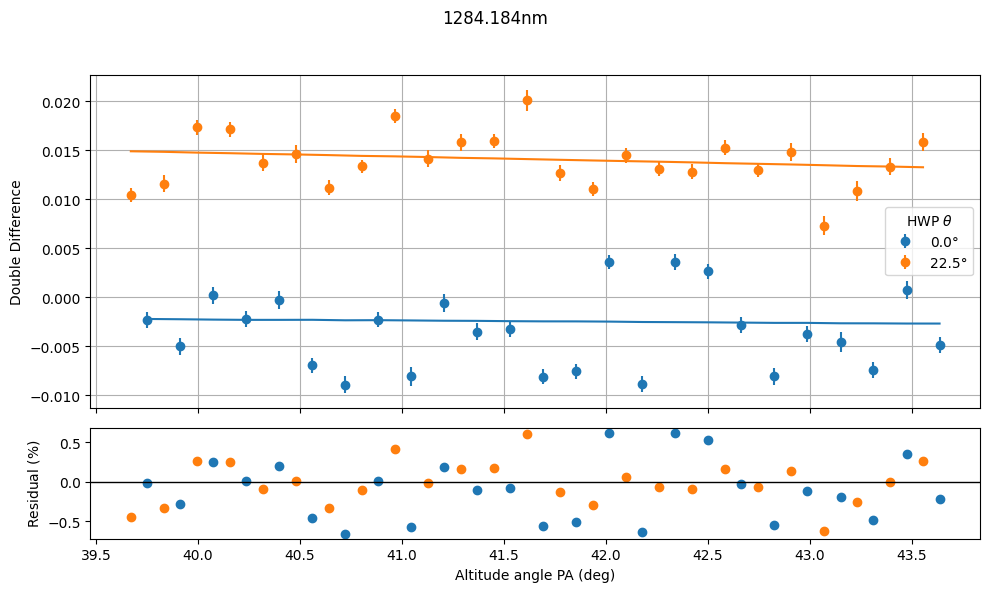

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

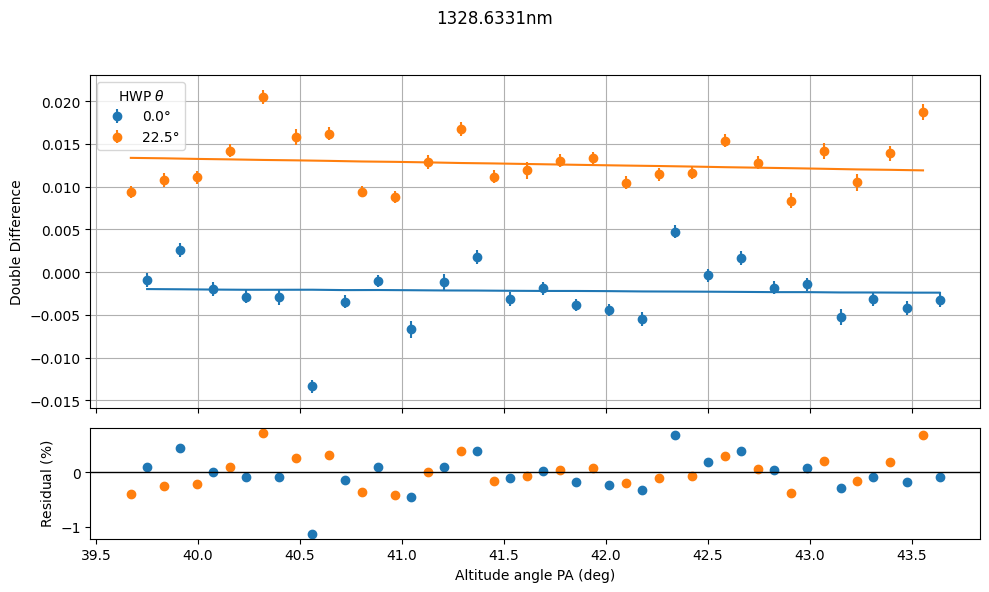

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

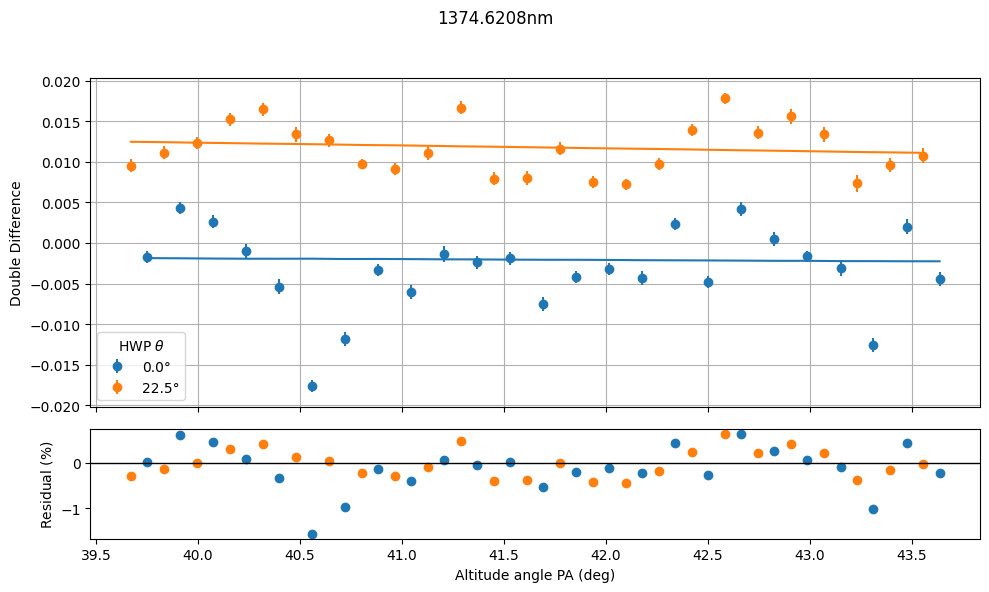

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

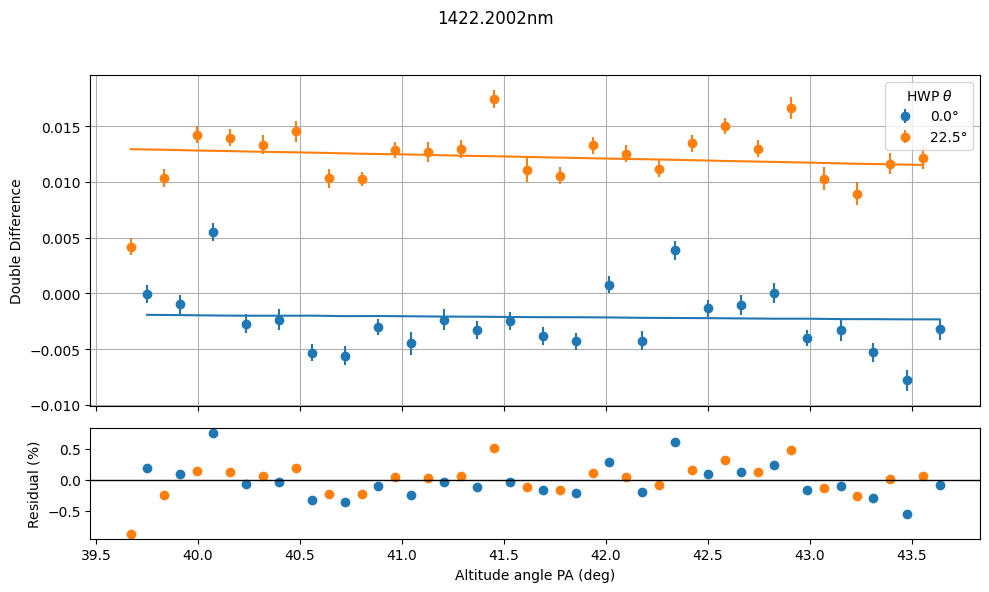

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

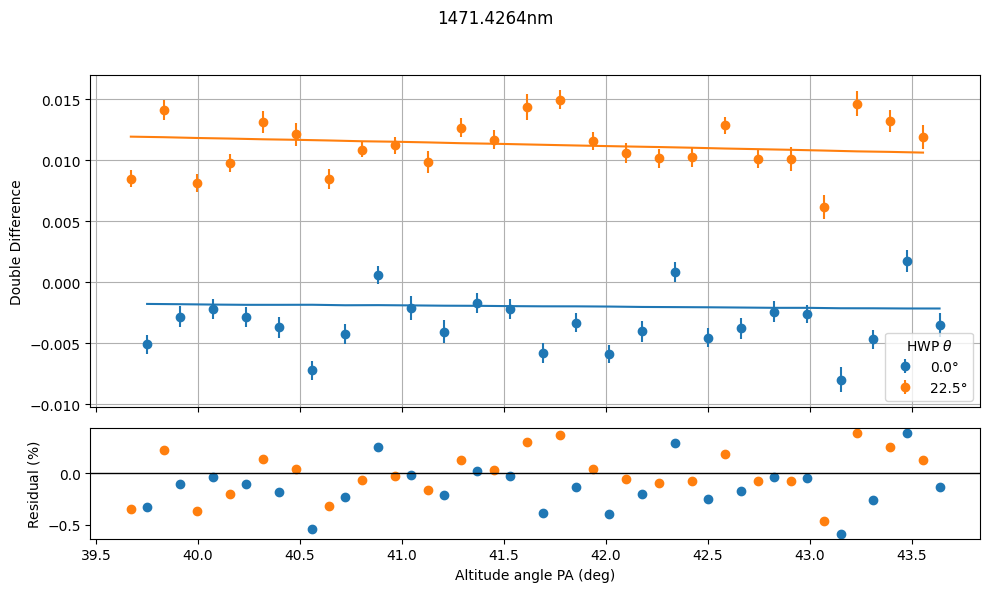

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

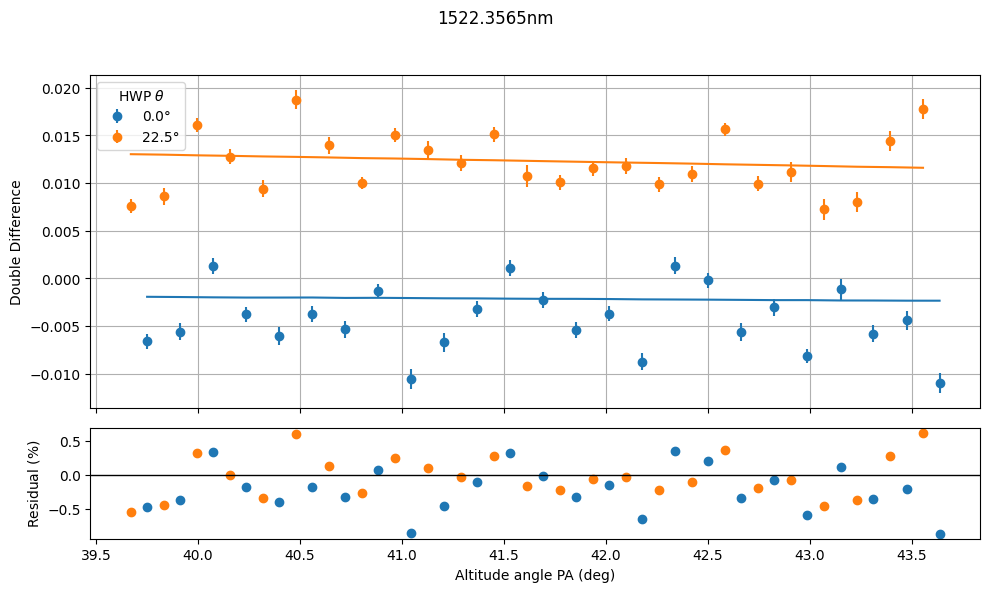

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

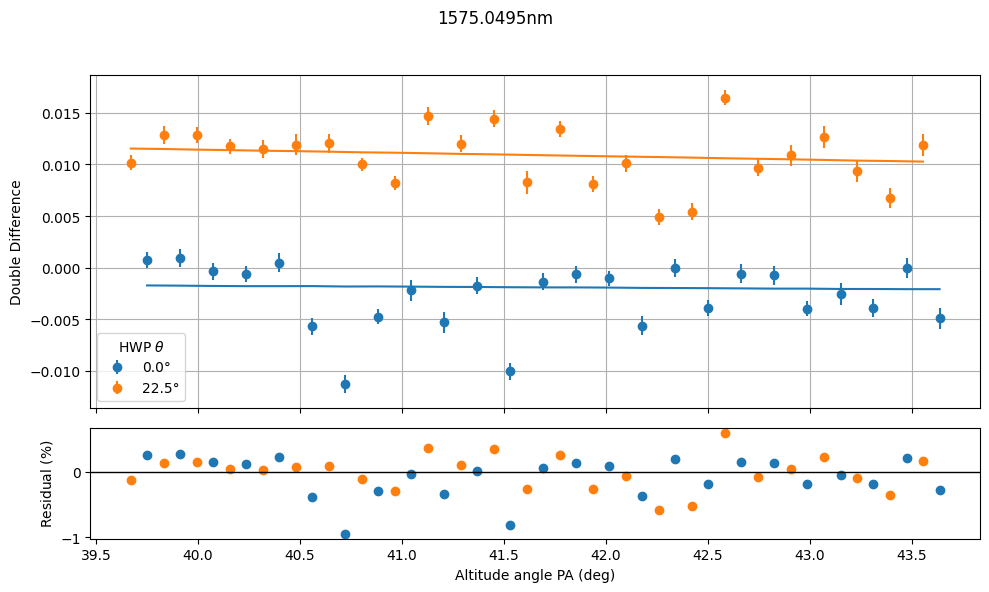

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

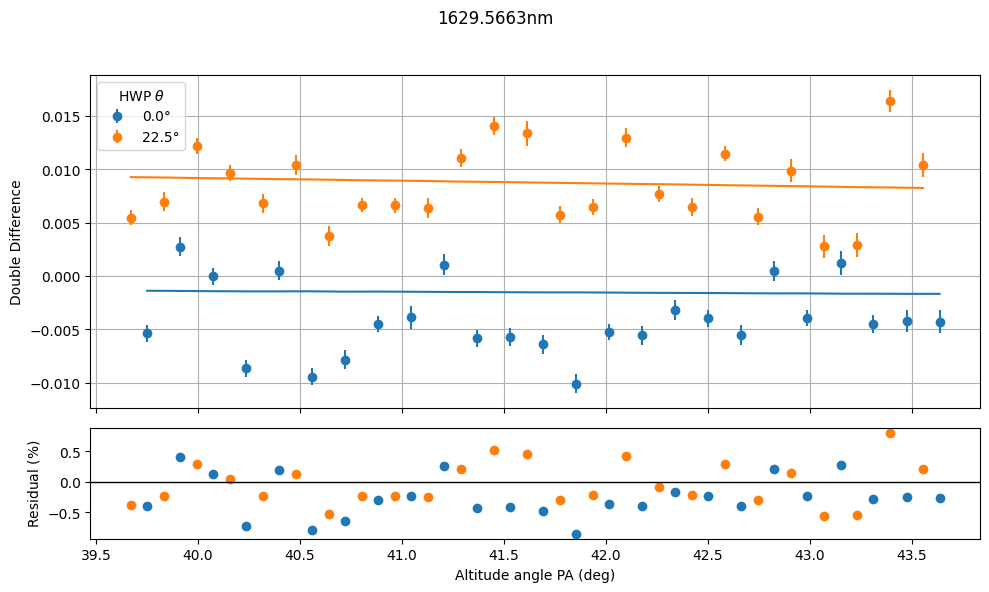

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

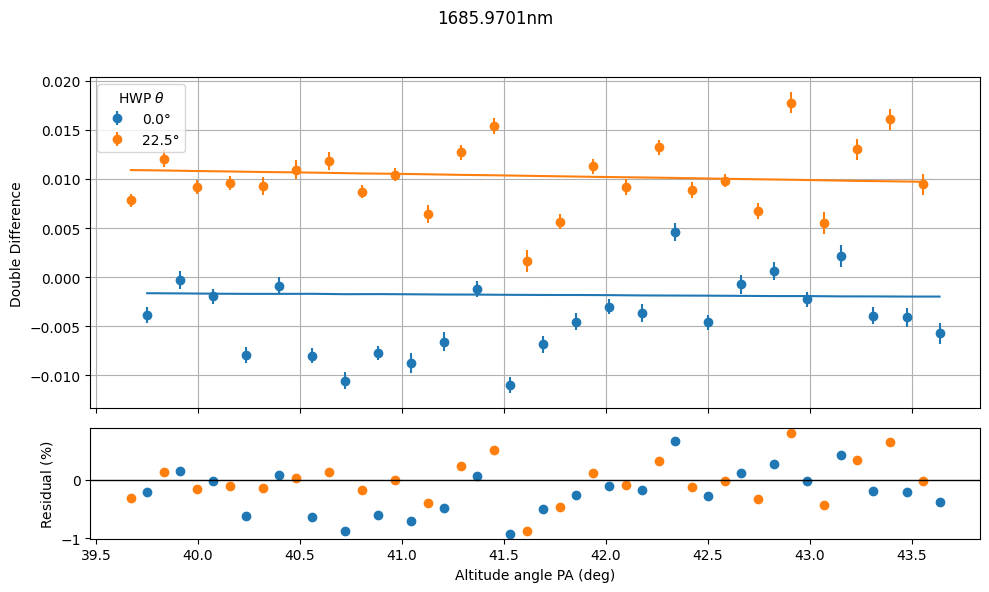

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

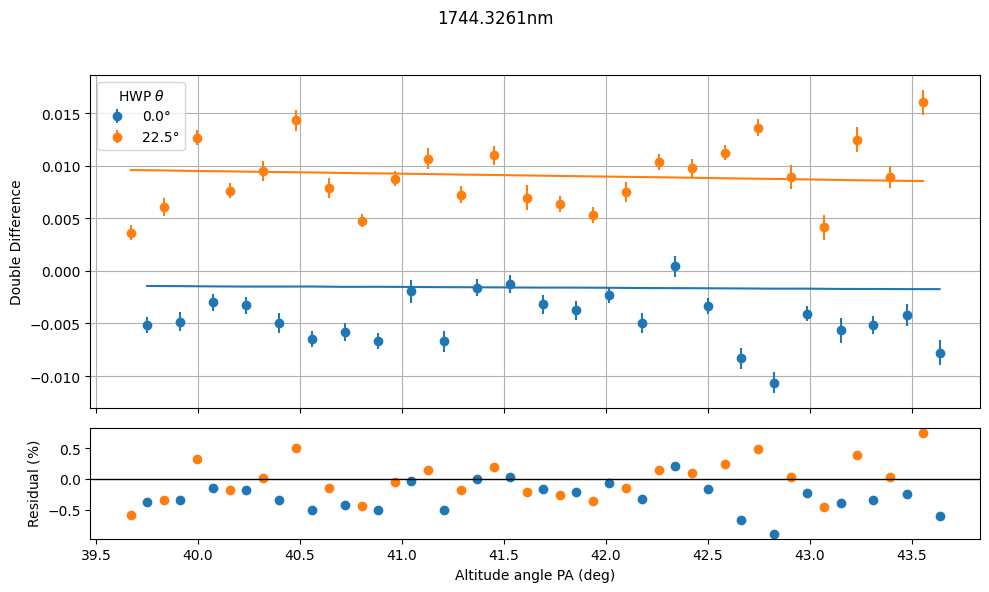

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

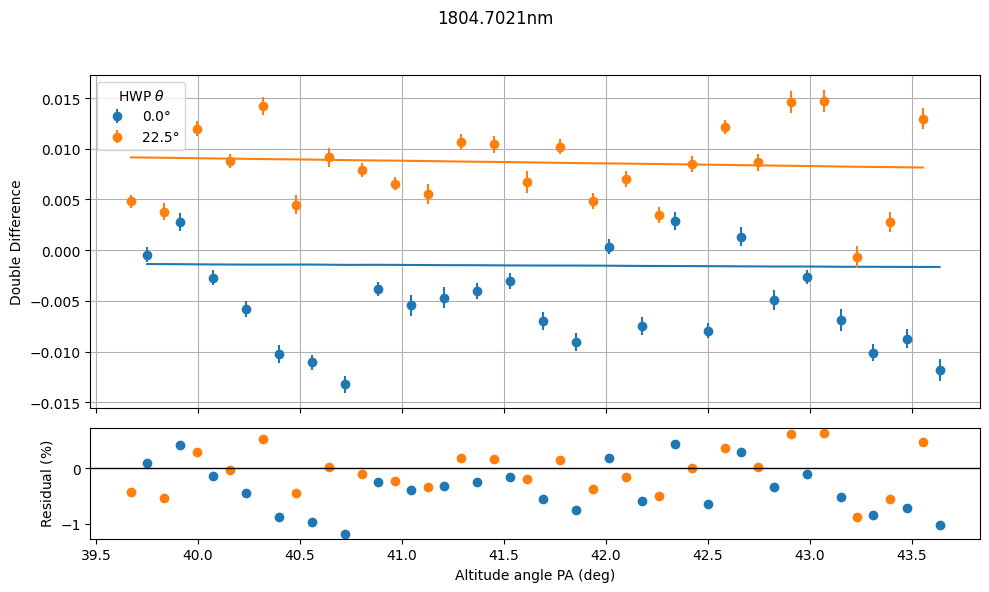

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

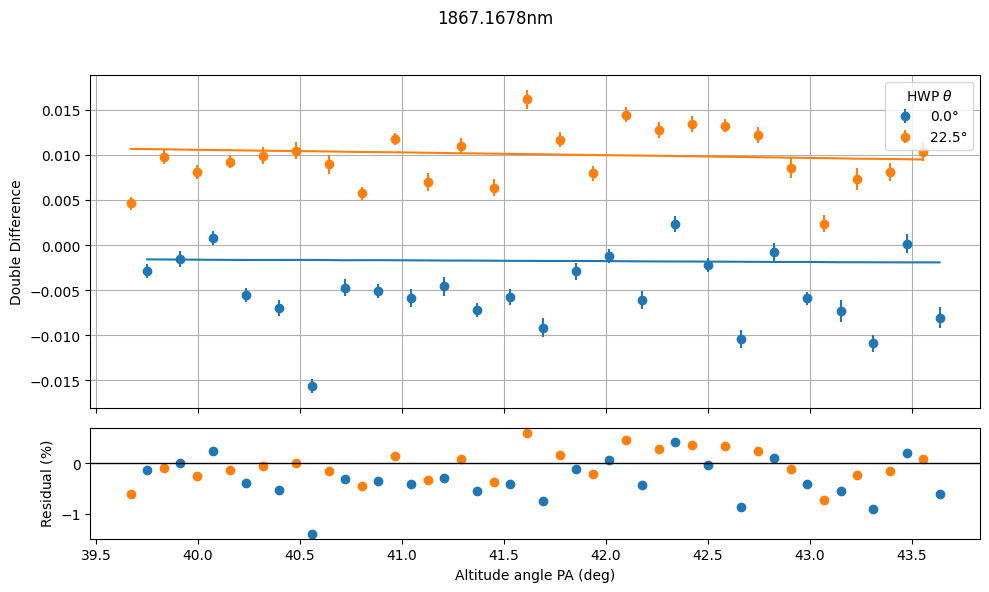

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

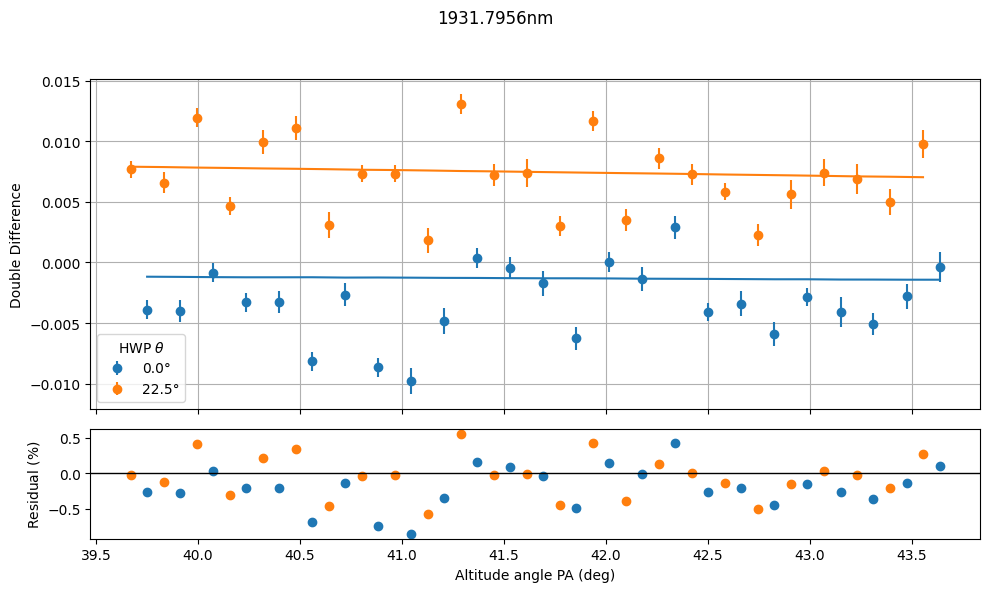

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

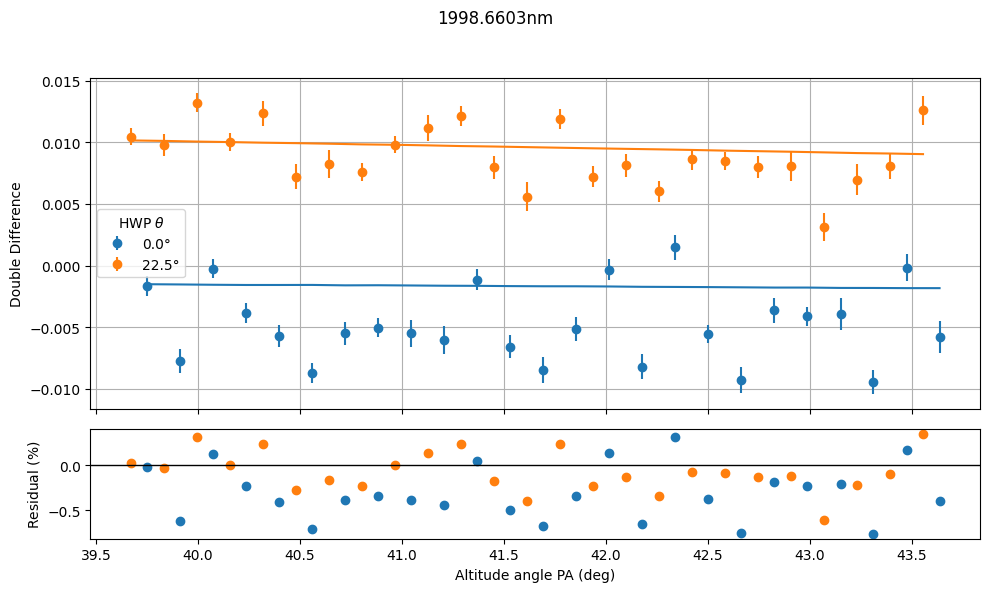

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

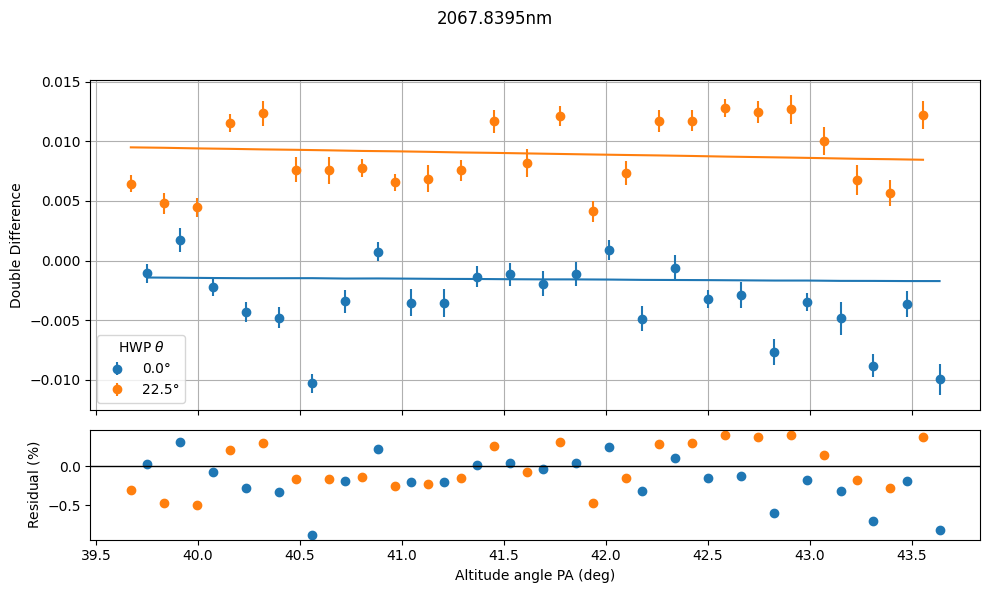

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

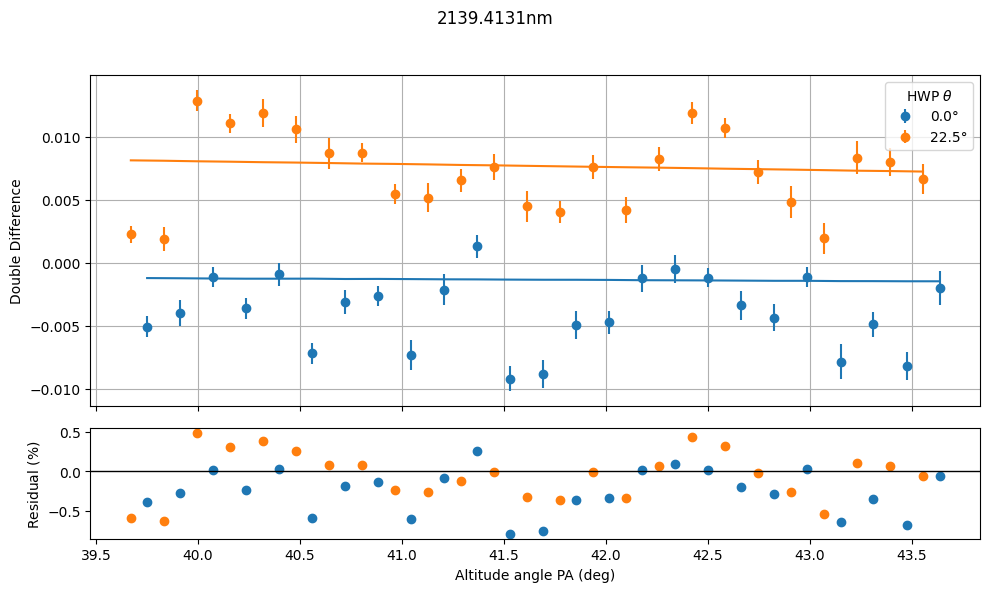

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

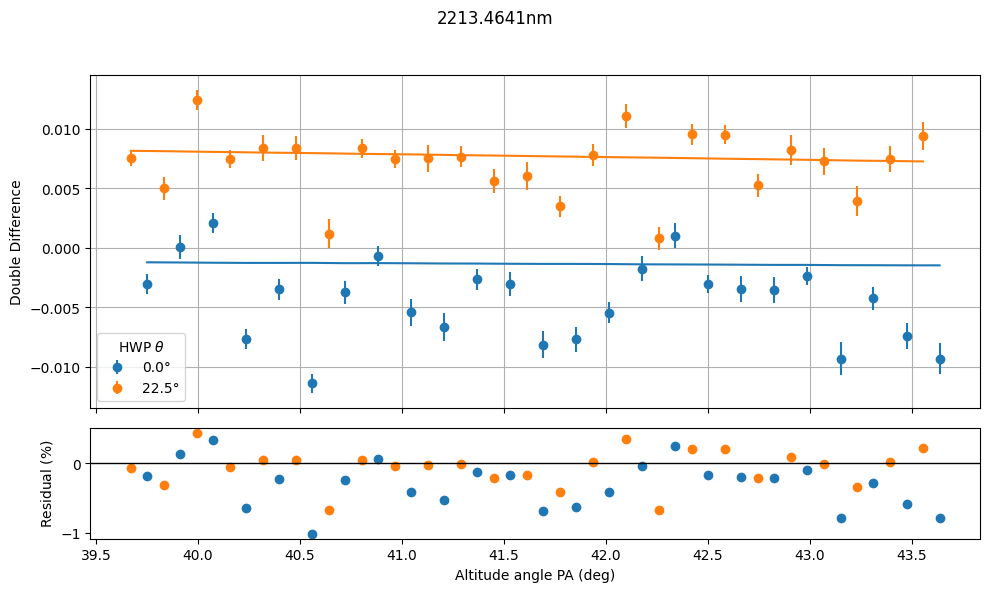

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

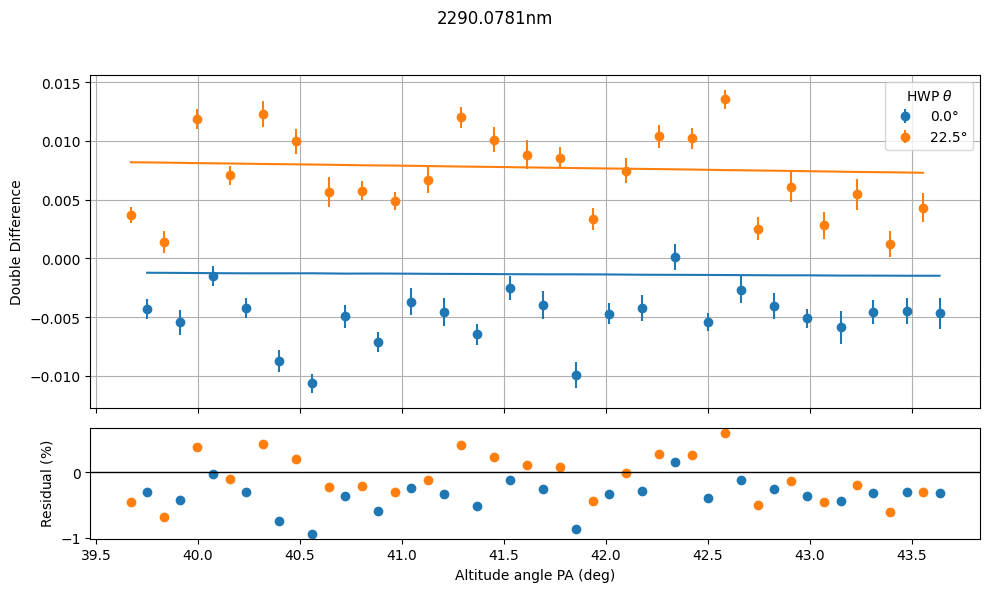

[{'hwp': {'theta': 82.84}, 'image_rotator': {'theta': 86.33203}, 'altitude_rot': {'pa': -43.63497933}, 'parang_rot': {'pa': 78.29422089232283}}, {'hwp': {'theta': 127.8}, 'image_rotator': {'theta': 86.30883}, 'altitude_rot': {'pa': -43.59460382}, 'parang_rot': {'pa': 78.28984909839794}}, {'hwp': {'theta': 105.22}, 'image_rotator': {'theta': 86.29572}, 'altitude_rot': {'pa': -43.55386223}, 'parang_rot': {'pa': 78.2853466221891}}, {'hwp': {'theta': 150.22}, 'image_rotator': {'theta': 86.27276}, 'altitude_rot': {'pa': -43.51350481}, 'parang_rot': {'pa': 78.28088650008564}}, {'hwp': {'theta': 82.67}, 'image_rotator': {'theta': 86.25071}, 'altitude_rot': {'pa': -43.47315017}, 'parang_rot': {'pa': 78.27648502754545}}, {'hwp': {'theta': 127.59}, 'image_rotator': {'theta': 86.22913}, 'altitude_rot': {'pa': -43.4327927}, 'parang_rot': {'pa': 78.2720136500403}}, {'hwp': {'theta': 105.05}, 'image_rotator': {'theta': 86.19789}, 'altitude_rot': {'pa': -43.39204501}, 'parang_rot': {'pa': 78.26751012

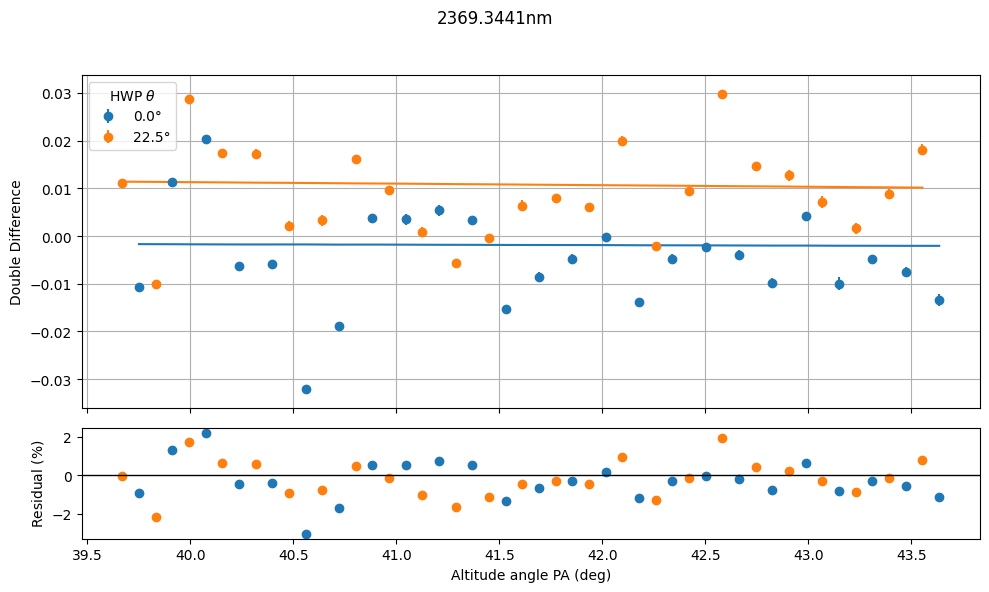

In [ ]:
from pyPolCal.csv_tools import read_csv 
from pyPolCal.utils import * 
from pyPolCal.fitting import minimize_system_mueller_matrix, model, process_dataset, process_model, process_errors, update_p0, update_system_mm
from pyPolCal.plotting import plot_data_and_model_alt
from pyPolCal.constants import wavelength_bins # all CHARIS wavelength bins
from pyMuellerMat.physical_models.charis_physical_models import * # Joost 't Hart 2021 physical models
import numpy as np
import json
from importlib.resources import files

s_abss = []
errors = []
for bin in range(22): # 22 wavelength bins

    ############ PREPARING MODEL #############

    # Define the path to the CSV file for the current bin
    fname = f'bin{bin}.csv'
    # going to use HD35532 instead, data seems better
    csvpath = files('pyPolCal.CHARIS.datacsvs.onsky_csvs.HD35532') / fname
    # Read csv
    interleaved_values, interleaved_stds, configuration_list = read_csv(csvpath, mode='m3') # SET M3 MODE
    print(configuration_list)
    # Load in system dictionary

    system_dict = {
    "components" : {
        "wollaston" : {
        "type" : "wollaston_prism_function",
        "properties" : {"beam": 'o', "eta": wollaston_eta[bin]}, 
        "tag": "internal",
        },

        "image_rotator" : {
        "type" : "fitted_derotator_function_july_2025",
        "properties" : {"delta_theta":-4.265e-02}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "two_layer_HWP_function", # Joost 't Hart 2021 HWP model
            "properties" : {"w_SiO2": 1.642, "w_MgF2": 1.283, "delta_theta": -2.975e-02},
            "tag": "internal",
        },

        "altitude_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        "M3" : {
            "type" : "diattenuator_retarder_function",
            "properties" : {"epsilon":0, "theta": 0, "delta_theta":0},
            "tag": "internal",
        },

        "parang_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
    }
    }

    # Converting system dictionary into system Mueller Matrix object
    system_mm = generate_system_mueller_matrix(system_dict)

    ############ FITTING #############

    # Starting guesses for all parameters, I'm taking mine from the Joost't Hart 2021 physical models
    hwp_retardance = HWP_retardance(wavelength_bins)[bin]
    imr_retardance = IMR_retardance(wavelength_bins)[bin]
    wol_eta = 1 # imperfect wollaston fit, using perfect as starting guess

    # p0 dictionary assigning parameters to their components in the system dictionary
    p0 = {
        "M3": {"epsilon":M3_diattenuation(wavelength_bins)[bin]}
    }

    # Set bounds for each component in order they appear in p0 dictionary
    retardance_bounds = (0,2*np.pi) 
    eta_bounds = (0,1)
    bounds_list = [(-1,1)]

    # Minimize, using process dataset and process model to process everything into double differences
    # Excluding double sums (always do this for CHARIS)
    # Not using aperture errors, works well for our large apertures

    result, new_logl, error = minimize_system_mueller_matrix(p0, system_mm, interleaved_values, 
    configuration_list, errors=interleaved_stds, process_errors=process_errors, process_dataset=process_dataset,process_model=process_model,include_sums=False, bounds = bounds_list,mode='least_squares')
    print(result)
    errors.append(error)

    ########## PLOTTING RESULTS ##########

    # Update p0 and system mueller matrix with fits
    update_p0(p0, result.x)
    p0_values, p0_keywords = parse_configuration(p0) # parsing updated p0 dictionary
    updated_system_mm = update_system_mm(p0_values, p0_keywords, system_mm)

    # Plot using instructions in plotting_a_model.ipynb
    interleaved_modeled = model(p0_values, p0_keywords, updated_system_mm, configuration_list, 
                                process_model=process_model,s_in=[1,0,0,0])

    # Inputting wavelength to use wavelength as the title
    plot_data_and_model_alt(interleaved_values, interleaved_modeled, configuration_list, interleaved_stds=interleaved_stds,
                                    wavelength=wavelength_bins[bin], include_sums=False)

    ########## CALCULATE S_REL ############

    # Processing single diffs/sums into double diffs/sums
    data_dd = process_dataset(interleaved_values)[::2] # only taking diffs

    # Only taking diffs                                              
    model_dd = interleaved_modeled[::2]

    # Converting resiudals to a percent
    residuals = data_dd*100 - model_dd*100

    # Calculating s_abs
    s_abs = np.sqrt(np.sum(residuals**2)/(len(data_dd)-len(p0_values)))
    s_abss.append(s_abs)


    ######### SAVING MODEL ###########

    updated_p0_path = f'../fitted_p_dicts/onsky_july2025/bin{bin}.json'
    with open (updated_p0_path, 'w') as f:
        json.dump(p0, f, indent=4)

not sure why this last bin is having issues

(0.0, 2.0)

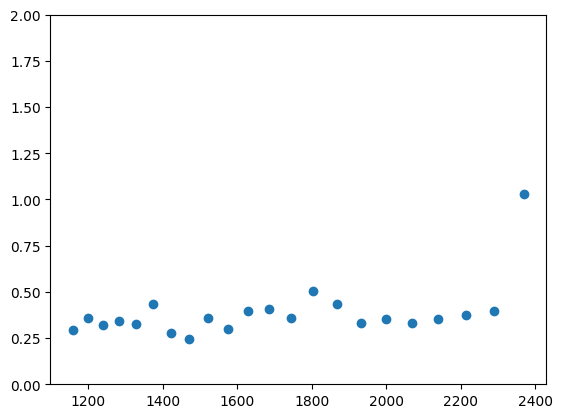

In [7]:
plt.scatter(wavelength_bins,s_abss)
plt.ylim(0,2)

Now for global fit

In [8]:
# IMPORTING DATA

from pyPolCal.csv_tools import read_csv_physical_model_all_bins
from importlib.resources import files
from pathlib import Path

# Defining Path to my CSVs
csvdir = Path('/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/HD35532')

# Reading in data
interleaved_values_all, interleaved_stds_all, configuration_list_all = read_csv_physical_model_all_bins(csvdir, m3=True)

In [9]:
# GENERATE MODEL
from pyPolCal.utils import generate_system_mueller_matrix

system_dict = {
    "components" : {
        "wollaston" : {
        "type" : "fitted_wollaston_function_july_2025",
        "properties" : {"beam": 'o'}, 
        "tag": "internal",
        },


         "image_rotator" : {
        "type" : "fitted_derotator_function_july_2025",
        "properties" : {"delta_theta":-4.265e-02}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "two_layer_HWP_function", # Joost 't Hart 2021 HWP model
            "properties" : {"w_SiO2": 1.642, "w_MgF2": 1.283, "delta_theta": -2.975e-02},
            "tag": "internal",
        },

        "altitude_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        "M3" : {
            "type" : "SUBARU_M3_function",
            "properties" : {"delta_theta":0},
            "tag": "internal",
        },

        "parang_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        },
}
system_mm = generate_system_mueller_matrix(system_dict)
system_mm.evaluate()

array([[ 0.5109442 ,  0.50917725, -0.02020011, -0.03734244],
       [ 0.5109442 ,  0.50917725, -0.02020011, -0.03734244],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

In [10]:
# DEFINE STARTING GUESSES AND BOUNDS

m1, b1, m2, b2 = (1.94073,13.69728,2.07958,13.88817) # from old MCMC
p0_dict = {
    "M3":{"m1": m1,
    "b1": b1,
    "m2": m2,
    "b2": b2
    }
}
m1_bounds = (0.5*m1, 2*m1)
m2_bounds = (0.5*m2, 2*m2)
b1_bounds = (0.5*b1, 2*b1)
b2_bounds = (0.5*b2, 2*b2)
boundslist = [m1_bounds, b1_bounds, m2_bounds, b2_bounds]

In [11]:
# MINIMIZE

from pyPolCal.fitting import minimize_system_mueller_matrix
from pyPolCal.utils import process_dataset, process_model, process_errors

result_min, logl_min=minimize_system_mueller_matrix(p0_dict,system_mm,interleaved_values_all,
                               configuration_list_all,errors= interleaved_stds_all, s_in=[1,0,0,0],process_errors = process_errors,process_dataset=process_dataset,
                               process_model=process_model,include_sums=False,
                               bounds=boundslist,mode='minimize')
print(result_min)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 4190.685674770912
        x: [ 1.864e+00  1.357e+01  2.028e+00  1.416e+01]
      nit: 40
      jac: [-3.044e+01  5.837e+00  1.880e+01 -2.996e+00]
     nfev: 260
     njev: 52
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
